In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import os
import matplotlib.font_manager as fm
import yfinance as yf
import datetime
from datetime import timedelta, datetime
import pptx as pptx
from openpyxl import load_workbook
from openpyxl.utils.dataframe import dataframe_to_rows
import xlwings as xw

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)

In [114]:
# ──────────────────────────────────────────────
#    CONFIGURAÇÃO DINÂMICA DE DATAS
#    Mês analisado  = mês anterior ao atual
#    Mês atual      = mês das próximas obrigações
# ──────────────────────────────────────────────
hoje = datetime.today()
mes_atual      = hoje.month   # ex: 5 (Maio)
ano_atual      = hoje.year    # ex: 2026

mes_anterior   = mes_atual - 1 if mes_atual > 1 else 12
ano_referencia = ano_atual     if mes_atual > 1 else ano_atual - 1

_abrev = {1:'jan', 2:'fev', 3:'mar', 4:'abr', 5:'mai', 6:'jun',
          7:'jul', 8:'ago', 9:'set', 10:'out', 11:'nov', 12:'dez'}

abrev_anterior = _abrev[mes_anterior]       # ex: 'abr'
abrev_atual    = _abrev[mes_atual]          # ex: 'mai'
ano_curto      = str(ano_referencia)[2:]    # ex: '26'

In [115]:
#============== CAMINHO DAS PASTAS ==============#
caminho_planilhas = r'G:\.shortcut-targets-by-id\1YZLLTFOuLniE6hO7WNHXl2c3MSa4TOv6\X. GAME11\GUARDIAN Institucional\5. Planejamento & Processos\2. 2023\4. Research\2026\17. Projetos\3. Zeladoria' 

#============== FONTES ==============#
caminho_Avenir = r'C:\\Users\\LucasCavalcante\\AppData\\Local\\Microsoft\\Windows\\Fonts\\Avenir Next LT Pro Regular.otf'
caminho_Geometeos = r'C:\\Users\\LucasCavalcante\\AppData\\Local\\Microsoft\\Windows\\Fonts\\Geometos Rounded.ttf'

#============== REGISTRANDO AS FONTES NO GERENCIADOR DO MATPLOTLIB ==============#
fm.fontManager.addfont(caminho_Avenir)
fm.fontManager.addfont(caminho_Geometeos)

#============== INSTALANDO AS FONTES ==============#
Avenir = fm.FontProperties(fname=caminho_Avenir)
Geometeos = fm.FontProperties(fname=caminho_Geometeos)

#============== FORCANDO O RECONHECIMENTO DAS FONTES ==============#
plt.rcParams['font.family'] = Avenir.get_name()

#============== TRANSFORMANDO A PLANILHA EM DATAFRAMES ==============#
roo = pd.read_excel(f"{caminho_planilhas}\\ROO_{abrev_anterior}{ano_curto}.xlsx")
status_imoveis = pd.read_excel(f"{caminho_planilhas}\\status_imoveis_{abrev_anterior}{ano_curto}.xlsx", sheet_name="Cadastral")

# 1.

Campo para limpeza e organização dos Dataframes

In [116]:
#==========================================#
#    LIMPANDO E EDITANDO OS DATAFRAMES
#==========================================#

#============== DATAFRAME DE ROTINAS ORDINARIAS (ROO) ==============#
df_roo = roo.drop(columns = ['Identificação da tarefa', 'Prioridade', 'Atribuído a', 
                             'Criado por', 'Criado em', 'Data de início', 
                             'É Recorrente', 'Concluída por', 'Itens concluídos da lista de verificação',
                              'Itens da lista de verificação', 'Descrição'])

df_roo = df_roo.rename(columns = {'Nome da tarefa':'Tarefa', 'Nome do Bucket':'Imovel', 
                                  'Data de conclusão':'Data_de_conclusao', 'Concluído em':'Concluido_em',
                                  'Rótulos':'Rotulos'})

df_roo['Data_de_conclusao'] = pd.to_datetime(
    df_roo['Data_de_conclusao'],
    format='%d/%m/%Y',
    errors='coerce'
)


#============== DATAFRAME DE STATUS IMÓVEIS ==============#
df_status_imoveis = status_imoveis.drop(columns = ['Observação'])

df_status_imoveis = df_status_imoveis.rename(columns={'imóveis':'Imoveis', 'Projeto Aprovado':'Projeto_Aprovado', 
                                                   'Construção Regularizada':'Construcao_Regularizada', 'Terreno Regularizado':'Terreno_regularizado', 
                                                   'Matricula c/ Construção Averbada':'Matricula_averbada', 'Alienação Averbada':'Alienacao_Averbada',
                                                   'Matricula Atualizada Completa':'Matricula_att_completa', 'Area construida (m²)':'Area_Construida',})

df_status_imoveis['Aluguel'] = (df_status_imoveis['Aluguel']/100).round(2)


# 2: Primeiro Dataframe

- Valor de aluguel consolidado por grupo

In [117]:
aluguel_total = df_status_imoveis['Aluguel'].sum()
consolidado_aluguel = df_status_imoveis.groupby(by = ['Grupo'])['Aluguel'].sum().reset_index()
consolidado_aluguel['% TOTAL'] = ((consolidado_aluguel['Aluguel']/aluguel_total)*100).round(2)
consolidado_aluguel

,Grupo,Aluguel,% TOTAL
0,ARTEMIS24,13761.93,5.03
1,BRL VI,7336.06,2.68
2,GARE,132754.03,48.56
3,GOPT,49291.69,18.03
4,IRIS,16102.66,5.89
5,XPRI,54160.95,19.81


# 3: Grafico de Donut do Aluguel

- Comparação entre o aluguel recebido pelo GARE11 comparado ao restante.

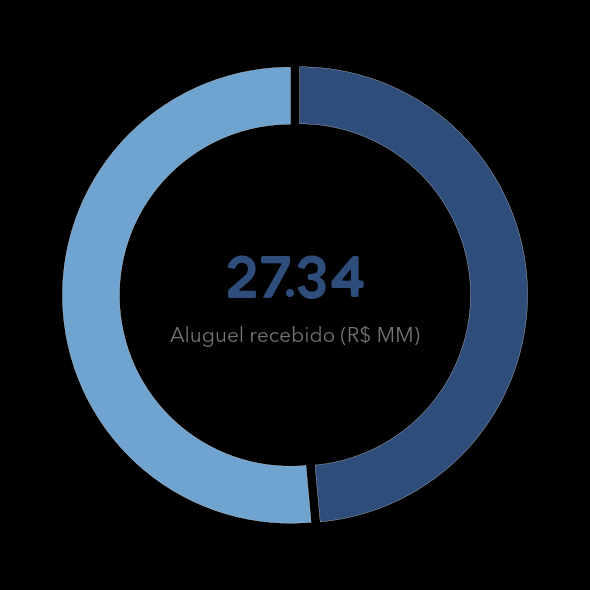

In [118]:

# ──────────────────────────────────────────────
# 1. DADOS
# ──────────────────────────────────────────────
df = consolidado_aluguel

valor_gare   = df.loc[df['Grupo'] == 'GARE', 'Aluguel'].values[0]
valor_outros = df.loc[df['Grupo'] != 'GARE', 'Aluguel'].sum()

total = valor_gare + valor_outros
total_ajustado = (total/10000).round(2)

labels = ['GARE', 'Outros Fundos']
values = [valor_gare, valor_outros]

colors     = ['#2E4D7B', '#6FA3D0']
explode    = (0.02, 0.02)

fig, ax = plt.subplots(figsize=(6, 6), facecolor='black')
ax.set_facecolor('black')

wedges, texts = ax.pie(
    values,
    labels=None,
    colors=colors,
    explode=explode,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(
        width=0.25,
        edgecolor='white',
        linewidth=0.2
    )
)

# ──────────────────────────────────────────────
# 4. TOTAL NO CENTRO DO DONUT
# ──────────────────────────────────────────────
ax.text(0, 0.08, str(total_ajustado),
        ha='center', va='center',
        fontsize=40, fontweight='bold', color='#2E4D7B',
        fontproperties=Geometeos)

ax.text(0, -0.18, 'Aluguel recebido (R$ MM)',
        ha='center', va='center',
        fontsize=15, color='#747474')


plt.tight_layout()
plt.savefig('donut_gare.png', transparent=True, dpi=150, bbox_inches='tight')
plt.show()

# 4: Segundo dataframe 

- Divisão das obrigações do mês atual: Concluídas x Não Iniciadas

In [119]:
# ──────────────────────────────────────────────
# 1. FILTRO DO MÊS ANTERIOR (mês analisado)
# ──────────────────────────────────────────────
df_abril = df_roo[
    (df_roo['Data_de_conclusao'].dt.month == mes_anterior) &
    (df_roo['Data_de_conclusao'].dt.year  == ano_referencia)
].copy()

# ──────────────────────────────────────────────
# 2. RESULTADO
# ──────────────────────────────────────────────
df_abril_progresso = df_abril.drop(columns=['Tarefa','Imovel','Atrasados','Concluido_em','Rotulos'])

df_abril_progresso = df_abril_progresso.groupby(by=['Progresso']).count()
df_abril_progresso

,Data_de_conclusao
Progresso,
Concluída,82
Não iniciado,3


# 5: Segundo Grafico de Donut

- Mostra a divisão entre as tarefas concluidas e as tarefas não iniciadas.

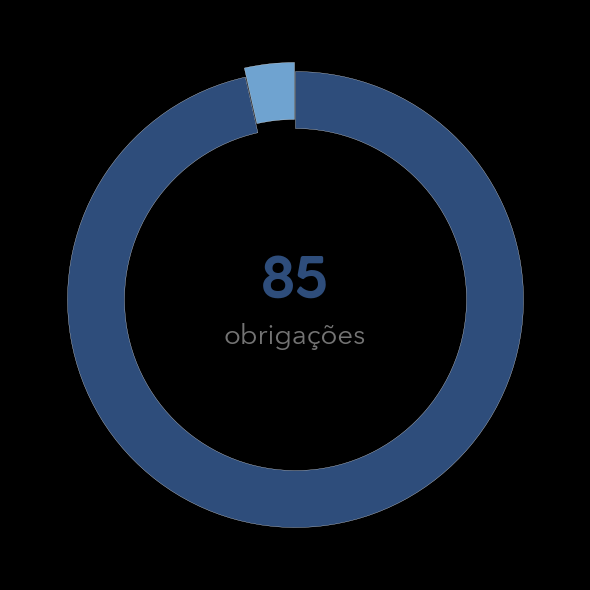

In [120]:
# ──────────────────────────────────────────────
# 1. EXTRAINDO OS VALORES DO DATAFRAME
# ──────────────────────────────────────────────
valor_concluida    = df_abril_progresso.loc['Concluída',    'Data_de_conclusao']
valor_nao_iniciado = df_abril_progresso.loc['Não iniciado', 'Data_de_conclusao']

total  = valor_concluida + valor_nao_iniciado
labels = ['Concluída', 'Não iniciado']
values = [valor_concluida, valor_nao_iniciado]

# ──────────────────────────────────────────────
# 2. GRÁFICO
# ──────────────────────────────────────────────
colors  = ['#2E4D7B', '#6FA3D0']
explode = (0.02, 0.02)

fig, ax = plt.subplots(figsize=(6, 6), facecolor='black')
ax.set_facecolor('black')

wedges, texts = ax.pie(
    values,
    labels=None,
    colors=colors,
    explode=explode,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(
        width=0.25,
        edgecolor='white',
        linewidth=0.2
    )
)

# ──────────────────────────────────────────────
# 5. TOTAL NO CENTRO DO DONUT
# ──────────────────────────────────────────────
ax.text(0, 0.08, str(total),
        ha='center', va='center',
        fontsize=40, fontweight='bold', color='#2E4D7B',
        fontproperties=Geometeos)

ax.text(0, -0.18, 'obrigações',
        ha='center', va='center',
        fontsize=20, color='#747474')


plt.tight_layout()
plt.savefig(f'donut_progresso_{abrev_anterior}.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

# 6: Terceiro Dataframe

- Separando por rotulos, mostra a quantidade de obrigações que foram concluidas e as que estão como "Não iniciado" 
- Referência ao mês atual.

In [121]:
df_abril_rotulos = df_abril.drop(columns=['Tarefa', 'Imovel', 'Data_de_conclusao', 'Atrasados', 'Concluido_em'])
df_abril_rotulos = df_abril_rotulos.groupby(by = ['Rotulos', 'Progresso'],as_index=False).size().rename(columns={'size':'Quantidade'})
df_abril_rotulos

,Rotulos,Progresso,Quantidade
0,Aluguel,Concluída,72
1,Carta Fiança,Concluída,2
2,IPTU,Concluída,1
3,IPTU,Não iniciado,3
4,Reajuste de Aluguel,Concluída,3
5,Seguro,Concluída,4


# 7: Primeiro grafico de barras horizontais.

- Separado por Rotulos, o grafico mostra a quantidade de tarefas concluidas e não iniciadas

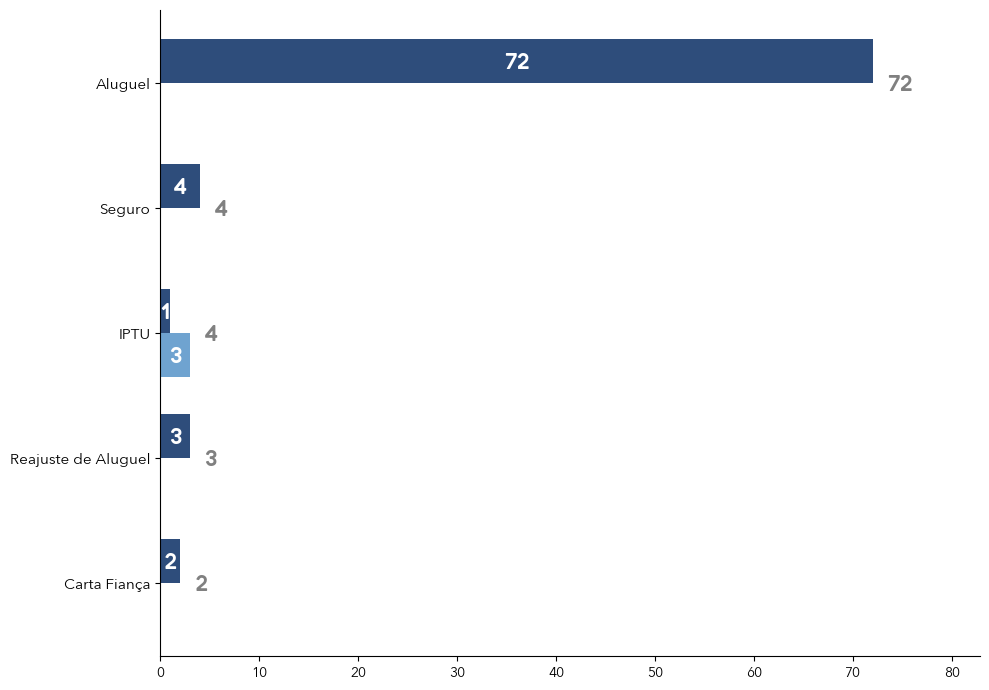

In [122]:
# ──────────────────────────────────────────────
# 1. PREPARAÇÃO DOS DADOS
# ──────────────────────────────────────────────
df_pivot = df_abril_rotulos.pivot(
    index='Rotulos',
    columns='Progresso',
    values='Quantidade'
).fillna(0).astype(int)

for col in ['Concluída', 'Não iniciado']:
    if col not in df_pivot.columns:
        df_pivot[col] = 0

df_pivot['Total'] = df_pivot['Concluída'] + df_pivot['Não iniciado']
df_pivot = df_pivot.sort_values('Total', ascending=True).drop(columns='Total')

# ──────────────────────────────────────────────
# 2. CONFIGURAÇÕES VISUAIS
# ──────────────────────────────────────────────
cores = {
    'Concluída':    '#2E4D7B',
    'Não iniciado': '#6FA3D0'
}

rotulos     = df_pivot.index.tolist()
concluidas  = df_pivot['Concluída'].tolist()
nao_inic    = df_pivot['Não iniciado'].tolist()
n           = len(rotulos)

altura      = 0.35
posicoes    = np.arange(n)

# ──────────────────────────────────────────────
# 3. FIGURA E EIXOS
# ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, n * 1.1 + 1.5), facecolor='white')
ax.set_facecolor('white')

# ──────────────────────────────────────────────
# 4. BARRAS
# ──────────────────────────────────────────────
barras_conc = ax.barh(
    posicoes + altura / 2,
    concluidas,
    height=altura,
    color=cores['Concluída'],
    label='Concluídas'
)

barras_nao = ax.barh(
    posicoes - altura / 2,
    nao_inic,
    height=altura,
    color=cores['Não iniciado'],
    label='Não Iniciadas'
)

# ──────────────────────────────────────────────
# 5. RÓTULOS DENTRO DAS BARRAS + TOTAL AO LADO
# ──────────────────────────────────────────────
total_max = max([c + n_ for c, n_ in zip(concluidas, nao_inic)])

for i, (c, ni) in enumerate(zip(concluidas, nao_inic)):
    total = c + ni

    if c > 0:
        ax.text(c / 2, i + altura / 2, str(c),
                va='center', ha='center',
                fontsize=15, fontweight='bold', color='white',
                fontproperties=Geometeos)

    if ni > 0:
        ax.text(ni / 2, i - altura / 2, str(ni),
                va='center', ha='center',
                fontsize=15, fontweight='bold', color='white',
                fontproperties=Geometeos)

    ax.text(max(c, ni) + total_max * 0.02, i, str(total),
            va='center', ha='left',
            fontsize=15, color='gray',
            fontproperties=Geometeos)

# ──────────────────────────────────────────────
# 6. EIXOS E ESTILO
# ──────────────────────────────────────────────
ax.set_yticks(posicoes)
ax.set_yticklabels(rotulos, fontsize=11)
ax.set_xlim(0, total_max * 1.15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.savefig(f'barras_rotulos_{abrev_anterior}.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

# 8: Quarto dataframe.

- Dataframe que mostra todos os Imoveis que possuem reajuste marcado para o mês atual.
- Usado na tabela "Reajuste Contratual - Detalhamento" do PowerPoint

In [123]:
df_abril_reajustes = df_abril.query('Rotulos == "Reajuste de Aluguel"').drop(columns=['Tarefa', 'Atrasados', 'Concluido_em', 'Rotulos']).rename(columns={'Data_de_conclusao':'Vencimento'})
df_abril_reajustes


,Imovel,Progresso,Vencimento
684,MATEUS - TIMON,Concluída,2026-04-22
1033,MATEUS - SOUSA,Concluída,2026-04-22
2149,MATEUS - JACOBINA,Concluída,2026-04-22


# 9: Quinto dataframe

- Dataframe base, não é utilizado na apresentação final
- Apenas mostra os status de regularização cadastral dividido por Grupo

In [124]:
regularizacao_cadastral = df_status_imoveis.drop(columns=['Imoveis','Aluguel','Tipo do Contrato', 'Vencimento do Contrato', 'Area_Construida', 'Alienacao_Averbada', 'Matricula_att_completa'])
regularizacao_cadastral

,Grupo,Projeto_Aprovado,Construcao_Regularizada,Terreno_regularizado,Matricula_averbada
0,GARE,Não,Ok,Ok,Não
1,GARE,Ok,Parcial,Ok,Parcial
2,GARE,Ok,Ok,Ok,Ok
3,GARE,Ok,Ok,Ok,Ok
4,XPRI,Ok,Ok,Ok,Não
...,...,...,...,...,...
71,GOPT,Ok,Ok,Ok,Ok
72,GARE,Ok,Ok,Ok,Ok
73,GARE,Ok,Ok,Ok,Ok
74,GARE,Ok,Ok,Ok,Ok


# 10: Segundo grafico de barras horizontais

- Baseado no dataframe acima, o grafico mostra a divisão das tarefas entre GARE11 e todos os outros imóveis.

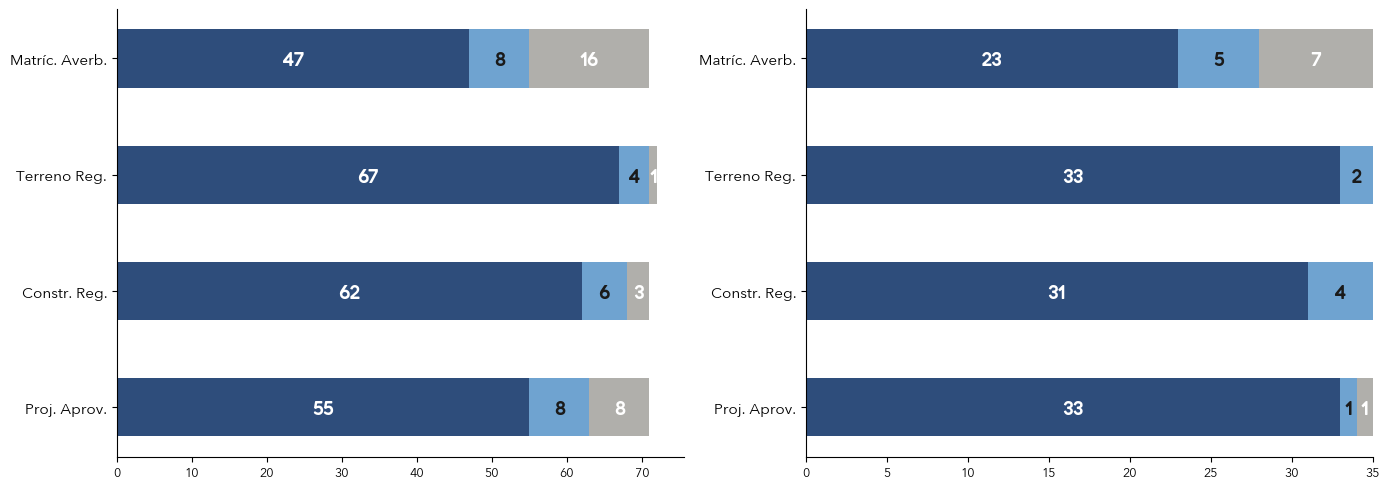

In [125]:
colunas = {
    'Projeto_Aprovado':        'Proj. Aprov.',
    'Construcao_Regularizada': 'Constr. Reg.',
    'Terreno_regularizado':    'Terreno Reg.',
    'Matricula_averbada':      'Matríc. Averb.'
}

categorias = ['Ok', 'Parcial', 'Não']

cores = {
    'Ok':      '#2E4D7B',
    'Parcial': '#6FA3D0',
    'Não':     '#B0AFAB'
}


def contar_categorias(df_input):
    resultado = {}
    for col in colunas.keys():
        contagem = df_input[col].value_counts(dropna=True)
        resultado[col] = {cat: contagem.get(cat, 0) for cat in categorias}
    return pd.DataFrame(resultado).T


df_total = contar_categorias(regularizacao_cadastral)
df_gare  = contar_categorias(regularizacao_cadastral[regularizacao_cadastral['Grupo'] == 'GARE'])

n_total = len(regularizacao_cadastral)
n_gare  = len(regularizacao_cadastral[regularizacao_cadastral['Grupo'] == 'GARE'])


def plotar_painel(ax, df_plot):
    rotulos_y = [colunas[c] for c in df_plot.index]
    n         = len(rotulos_y)
    altura    = 0.5
    acumulado = np.zeros(n)

    for cat in categorias:
        valores = df_plot[cat].values

        ax.barh(
            range(n),
            valores,
            left=acumulado,
            height=altura,
            color=cores[cat],
            label=cat
        )

        for i, (val, esq) in enumerate(zip(valores, acumulado)):
            if val > 0:
                ax.text(
                    esq + val / 2, i, str(val),
                    va='center', ha='center',
                    fontsize=13, fontweight='bold',
                    color='white' if cat in ['Ok', 'Não'] else '#1a1a1a',
                    fontproperties=Geometeos
                )

        acumulado += valores

    ax.set_yticks(range(n))
    ax.set_yticklabels(rotulos_y, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=9)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
ax1.set_facecolor('white')
ax2.set_facecolor('white')

plotar_painel(ax1, df_total)
plotar_painel(ax2, df_gare)

handles = [
    plt.Rectangle((0,0), 1, 1, color=cores[cat], label=cat)
    for cat in categorias
]

plt.tight_layout()
plt.savefig('regularizacao_cadastral.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

# 11: Tabela de Percentual de andamento da regularização ----- GARE11xTOTAL

- Usado para montar a tabela de percentual do slide 3 - Tópico "Regularização Cadastral dos imóveis"

In [126]:
# ──────────────────────────────────────────────
#    PERCENTUAL DE CONCLUSÃO DAS OBRIGAÇÕES
# ──────────────────────────────────────────────

# ──────────────────────────────────────────────
# 1. FUNÇÃO DE PERCENTUAL DE OK
# Recebe um DataFrame e retorna o % de 'Ok'
# em relação ao total de não-nulos por coluna
# ──────────────────────────────────────────────
def percentual_ok(df_input):
    resultado = {}
    for col in colunas.keys():
        serie      = df_input[col].dropna()
        total      = len(serie)
        qtd_ok     = (serie == 'Ok').sum()
        resultado[colunas[col]] = f"{round(qtd_ok / total * 100)}%" if total > 0 else "—"
    return resultado


# ──────────────────────────────────────────────
# 2. CALCULA PARA TOTAL E GARE
# ──────────────────────────────────────────────
pct_total = percentual_ok(regularizacao_cadastral)
pct_gare  = percentual_ok(regularizacao_cadastral[regularizacao_cadastral['Grupo'] == 'GARE'])


# ──────────────────────────────────────────────
# 3. MONTA O DATAFRAME DA TABELA
# ──────────────────────────────────────────────
df_tabela = pd.DataFrame({
    'TOTAL': pct_total,
    'GARE':  pct_gare
})

df_tabela

,TOTAL,GARE
Proj. Aprov.,77%,94%
Constr. Reg.,87%,89%
Terreno Reg.,93%,94%
Matríc. Averb.,66%,66%


# 12

In [127]:
# ──────────────────────────────────────────────
# 1. FILTRO DE JANEIRO ATÉ O FIM DO MÊS ANTERIOR
# ──────────────────────────────────────────────
data_inicio = pd.Timestamp(ano_referencia, 1, 1)
data_fim    = pd.Timestamp(ano_referencia, mes_anterior, 1) + pd.offsets.MonthEnd(0)


df_jan_abr = df_roo[
    df_roo['Data_de_conclusao'].between(data_inicio, data_fim)
].copy().query('Atrasados == True').drop(columns = ['Tarefa', 'Imovel', 'Progresso', 'Data_de_conclusao', 'Concluido_em']).groupby('Rotulos')['Atrasados'].count().reset_index()
df

df_jan_abr

,Rotulos,Atrasados
0,AVCB,3
1,IPTU,6
2,Não Ocorrência de Recompra,14
3,Seguro,31
4,Taxa de Bombeiro,1


# 13

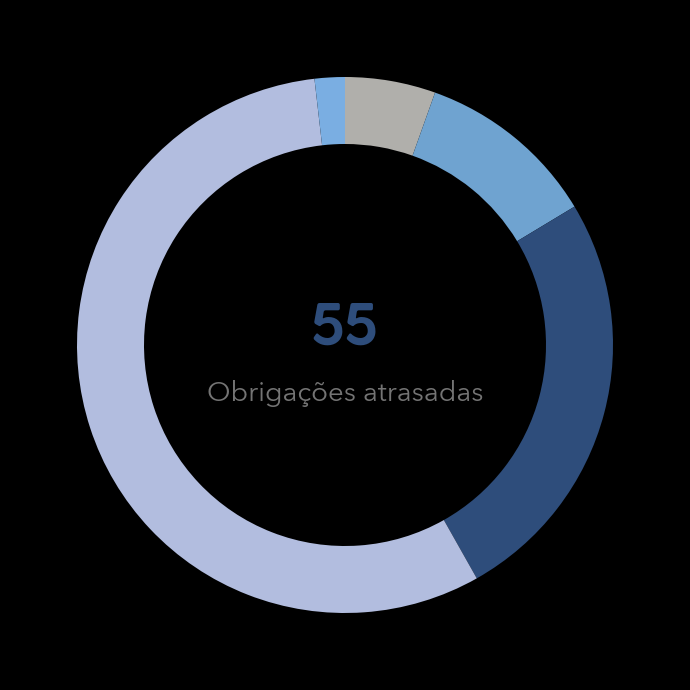

In [128]:
labels = df_jan_abr['Rotulos'].tolist()
values = df_jan_abr['Atrasados'].tolist()
total  = sum(values)

cores = ['#B0AFAB', '#6FA3D0', '#2E4D7B', '#B2BDDF', '#7AAEE2', '#EAE7E8']

fig, ax = plt.subplots(figsize=(7, 7), facecolor='black')
ax.set_facecolor('black')

wedges, texts = ax.pie(
    values,
    labels=None,
    colors=cores,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(
        width=0.25,
        edgecolor='none',
        linewidth=0
    )
)

ax.text(0, 0.08, str(total),
        ha='center', va='center',
        fontsize=40, fontweight='bold', color='#2E4D7B',
        fontproperties=Geometeos)

ax.text(0, -0.18, 'Obrigações atrasadas',
        ha='center', va='center',
        fontsize=20, color='#747474')

plt.tight_layout()
plt.savefig('donut_atrasados.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

# 14: Tabela de Status das Averbações de Matricula

- Slide 4
- Tópico 05: "Imóveis com pendências na averbação de Matrícula"

In [129]:
df_averb = df_status_imoveis.drop(columns=['Aluguel', 'Tipo do Contrato', 'Vencimento do Contrato',
                                           'Projeto_Aprovado', 'Construcao_Regularizada', 'Terreno_regularizado',
                                           'Alienacao_Averbada', 'Matricula_att_completa', 'Area_Construida']).query('Matricula_averbada != "Ok"').dropna()
df_averb

,Imoveis,Grupo,Matricula_averbada
0,AIRLIQUID CANOAS,GARE,Não
1,AIRLIQUID SÃO JOSÉ DOS CAMPOS,GARE,Parcial
4,BRF SALVADOR,XPRI,Não
5,BRF VISA,IRIS,Parcial
7,BRL VI - ARTERIS (RIBERÃO),BRL VI,Parcial
25,CARREFOUR - ATC 42 (MARINGÁ FERN DIAS),GARE,Parcial
26,CARREFOUR - ATC 45 (CUIABÁ TIJ),GARE,Parcial
27,GPA - ABILIO SOARES,GARE,Não
28,GPA - ANGÉLICA,GARE,Não
29,GPA - BUZIOS,GARE,Não


# 15: Cards de próximos vencimentos

- Slide 4
- Tópico 06: "Próximos vencimentos - ABR26 (ANUAIS)

In [130]:
# ──────────────────────────────────────────────
# 1. FILTRO DO MÊS ATUAL (próximas obrigações)
# ──────────────────────────────────────────────
df_maio = df_roo[
    (df_roo['Data_de_conclusao'].dt.month == mes_atual) &
    (df_roo['Data_de_conclusao'].dt.year  == ano_atual)
].copy()

# ──────────────────────────────────────────────
# 2. RESULTADO
# ──────────────────────────────────────────────
df_maio_tarefas = df_maio.drop(columns=['Tarefa','Imovel','Atrasados','Concluido_em']).query('Rotulos != "Aluguel"').groupby(by = ['Rotulos', 'Progresso']).count()
df_maio_tarefas

Data_de_conclusao
Rotulos             Progresso                      
AVCB                Concluída                     3
                    Não iniciado                  6
Avaliação de Imóvel Não iniciado                 23
IPTU                Concluída                     1
                    Não iniciado                  9
Reajuste de Aluguel Não iniciado                  2
Seguro              Não iniciado                  1

# 16

In [131]:
df_maio_tarefas_total = df_maio.drop(columns=['Tarefa','Imovel','Atrasados','Concluido_em']).query('Rotulos != "Aluguel"').groupby(by = ['Progresso']).count()
df_maio_tarefas_total

,Data_de_conclusao,Rotulos
Progresso,,
Concluída,4,4
Não iniciado,41,41


# 17

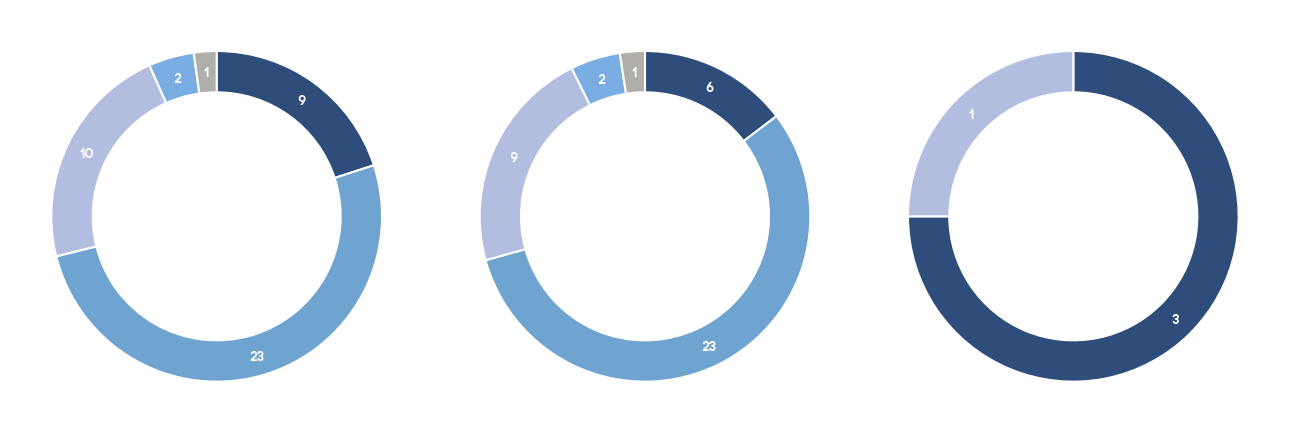

In [132]:
df_maio_tarefas = df_maio_tarefas.reset_index()
df_maio_tarefas.columns = ['Rotulos', 'Progresso', 'Quantidade']

df_total = (
    df_maio_tarefas
    .groupby('Rotulos')['Quantidade']
    .sum()
    .reset_index()
)

df_pendentes = (
    df_maio_tarefas[df_maio_tarefas['Progresso'] == 'Não iniciado']
    [['Rotulos', 'Quantidade']]
    .reset_index(drop=True)
)

df_concluidas = (
    df_maio_tarefas[df_maio_tarefas['Progresso'] == 'Concluída']
    [['Rotulos', 'Quantidade']]
    .reset_index(drop=True)
)

todos_rotulos = df_total['Rotulos'].tolist()

paleta = ['#2E4D7B', '#6FA3D0', '#B2BDDF', '#7AAEE2', '#B0AFAB', '#EAE7E8']

mapa_cores = {rot: paleta[i % len(paleta)] for i, rot in enumerate(todos_rotulos)}


def plotar_donut(ax, df_painel):
    labels  = df_painel['Rotulos'].tolist()
    values  = df_painel['Quantidade'].tolist()
    cores   = [mapa_cores[r] for r in labels]
    total   = sum(values)

    if total == 0:
        ax.pie(
            [1],
            colors=['#E0E0E0'],
            wedgeprops=dict(width=0.25, edgecolor='white', linewidth=1.5)
        )
        ax.text(0, 0, '0', ha='center', va='center',
                fontsize=18, fontweight='bold', color='#333333',
                fontproperties=Geometeos)
        return

    wedges, texts = ax.pie(
        values,
        labels=None,
        colors=cores,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(
            width=0.25,
            edgecolor='white',
            linewidth=1.5
        )
    )

    for wedge, val in zip(wedges, values):
        angulo_centro = (wedge.theta1 + wedge.theta2) / 2
        rad           = np.deg2rad(angulo_centro)
        raio_texto    = 1 - 0.25 / 2
        x = raio_texto * np.cos(rad)
        y = raio_texto * np.sin(rad)
        ax.text(x, y, str(val),
                ha='center', va='center',
                fontsize=9, fontweight='bold', color='white',
                fontproperties=Geometeos)


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 5), facecolor='white')

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor('white')

plotar_donut(ax1, df_total)
plotar_donut(ax2, df_pendentes)
plotar_donut(ax3, df_concluidas)

plt.tight_layout()
plt.savefig('vencimentos_categoria.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

# 18: Tabela de detalhamento das tarefas pendentes

- Slide 4
- Tópico 06: "Detalhamento - Tarefas Pendentes"

In [133]:
df_maio_detalhamento = (
    df_maio
    .query('Progresso == "Não iniciado" and Rotulos != "Aluguel"')
    .drop(columns=['Tarefa', 'Atrasados', 'Concluido_em'])
    .sort_values(by='Data_de_conclusao', ascending=True)
    .head(10)
    .rename(columns = {'Progresso':'Status', 'Data_de_conclusao':'Vencimento', 'Rotulos':'Obrigacão'})
)

df_maio_detalhamento = df_maio_detalhamento[['Imovel', 'Obrigacão', 'Vencimento', 'Status']]
df_maio_detalhamento

,Imovel,Obrigacão,Vencimento,Status
1724,CARREFOUR - ATC 179 (BOA VISTA),IPTU,2026-05-05,Não iniciado
930,GPA - SANTO ANDRÉ VILA GILDA,AVCB,2026-05-05,Não iniciado
240,CARREFOUR - ATC 197 (LUCAS DO RIO VERDE),IPTU,2026-05-08,Não iniciado
1100,MATEUS - ITABUNA,Reajuste de Aluguel,2026-05-12,Não iniciado
1125,MATEUS - MACEIO,Reajuste de Aluguel,2026-05-12,Não iniciado
1865,CARREFOUR - ATC 158 (FORTALEZA EUSÉBIO),Avaliação de Imóvel,2026-05-15,Não iniciado
1796,SICREDI - BELÉM,Avaliação de Imóvel,2026-05-15,Não iniciado
1721,SICREDI - SARANDI (SEDE),Avaliação de Imóvel,2026-05-15,Não iniciado
1679,CARREFOUR - ATC 137 (CAMPO GRANDE AERO),Avaliação de Imóvel,2026-05-15,Não iniciado
1587,SICREDI - SÃO JOSÉ/RJ,Avaliação de Imóvel,2026-05-15,Não iniciado


# 19

In [134]:
df_data_vencimento = df_status_imoveis.drop(columns=['Projeto_Aprovado', 'Construcao_Regularizada', 'Terreno_regularizado', 
                                                     'Matricula_averbada', 'Alienacao_Averbada', 'Matricula_att_completa', 'Area_Construida'])

soma_aluguel = df_data_vencimento['Aluguel'].sum()

df_data_vencimento['Participacao_aluguel'] = ((df_data_vencimento['Aluguel']/soma_aluguel)*100).round(2)

df_data_vencimento

,Imoveis,Grupo,Aluguel,Tipo do Contrato,Vencimento do Contrato,Participacao_aluguel
0,AIRLIQUID CANOAS,GARE,1156.89,Atipico,2031-03-21 00:00:00,0.42
1,AIRLIQUID SÃO JOSÉ DOS CAMPOS,GARE,1428.34,Atipico,21/03/2031,0.52
2,ALMANARA,GARE,3521.58,Atipico,12/11/2037,1.29
3,BAT - CACHOERINHA,GARE,27194.26,Atipico,29/08/2027,9.95
4,BRF SALVADOR,XPRI,27147.06,Atipico,01/06/2028,9.93
...,...,...,...,...,...,...
71,CARREFOUR - ATC 325 (VALENÇA),GOPT,2416.67,Atipico,2040-12-18 00:00:00,0.88
72,CONFINS - 3 CORAÇÕES,GARE,2206.02,Atipico,2029-02-28 00:00:00,0.81
73,CONFINS - VALE,GARE,2601.70,Tipico,2030-07-31 00:00:00,0.95
74,CONFINS - MELI,GARE,1511.67,Tipico,2030-11-02 00:00:00,0.55


# 20

C:\Users\LucasCavalcante\AppData\Local\Temp\ipykernel_23236\1977778720.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data_vencimento['Ano'] = df_data_vencimento['Vencimento do Contrato'].dt.year
C:\Users\LucasCavalcante\AppData\Local\Temp\ipykernel_23236\1977778720.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data_vencimento['Bucket'] = df_data_vencimento['Ano'].apply(bucket_ano)
C:\Users\LucasCavalcante\AppData\Local\Temp\ipykernel_23236\1977778720.py:138: UserWarning: This figure incl

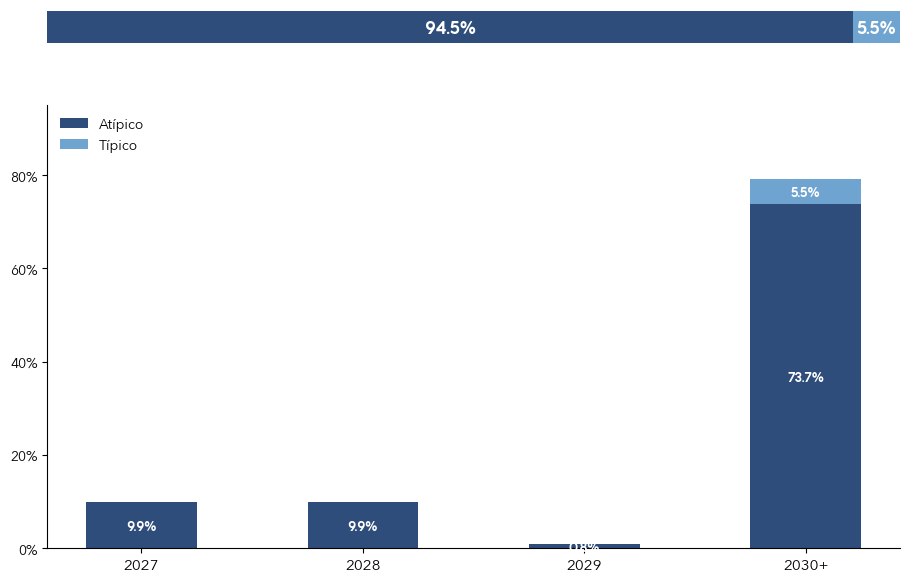

In [135]:
# ──────────────────────────────────────────────
# 1. CONVERSÃO DA COLUNA DE DATAS
# ──────────────────────────────────────────────
df_data_vencimento['Vencimento do Contrato'] = (
    df_data_vencimento['Vencimento do Contrato']
    .replace('-', pd.NaT)
    .pipe(pd.to_datetime, dayfirst=True, errors='coerce')
)

df_data_vencimento = df_data_vencimento.dropna(subset=['Vencimento do Contrato'])
df_data_vencimento['Ano'] = df_data_vencimento['Vencimento do Contrato'].dt.year

# ──────────────────────────────────────────────
# 2. BUCKET DE ANOS
# ──────────────────────────────────────────────
def bucket_ano(ano):
    if ano <= 2029:
        return str(ano)
    return '2030+'

df_data_vencimento['Bucket'] = df_data_vencimento['Ano'].apply(bucket_ano)

# ──────────────────────────────────────────────
# 3. AGREGAÇÃO
# ──────────────────────────────────────────────
df_grouped = (
    df_data_vencimento
    .groupby(['Bucket', 'Tipo do Contrato'])['Participacao_aluguel']
    .sum()
    .reset_index()
)

df_pivot = df_grouped.pivot(
    index='Bucket',
    columns='Tipo do Contrato',
    values='Participacao_aluguel'
).fillna(0)

for col in ['Tipico', 'Atipico']:
    if col not in df_pivot.columns:
        df_pivot[col] = 0

ordem = sorted([b for b in df_pivot.index if b != '2030+'],
               key=lambda x: int(x)) + ['2030+']
df_pivot = df_pivot.loc[ordem]

# ──────────────────────────────────────────────
# 4. TOTAIS
# ──────────────────────────────────────────────
total_tipico  = df_pivot['Tipico'].sum()
total_atipico = df_pivot['Atipico'].sum()
total_geral   = total_tipico + total_atipico

cor_atipico = '#2E4D7B'
cor_tipico  = '#6FA3D0'

# ──────────────────────────────────────────────
# 5. FIGURA
# ──────────────────────────────────────────────
fig = plt.figure(figsize=(11, 7), facecolor='white')
gs  = fig.add_gridspec(2, 1, height_ratios=[0.08, 1], hspace=0.25)

ax_top  = fig.add_subplot(gs[0])
ax_main = fig.add_subplot(gs[1])

for ax in [ax_top, ax_main]:
    ax.set_facecolor('white')

# ──────────────────────────────────────────────
# 6. BARRA SUPERIOR
# ──────────────────────────────────────────────
ax_top.barh(0, total_atipico / total_geral * 100,
            color=cor_atipico, height=0.6)
ax_top.barh(0, total_tipico / total_geral * 100,
            left=total_atipico / total_geral * 100,
            color=cor_tipico, height=0.6)

ax_top.text(total_atipico / total_geral * 50, 0,
            f"{total_atipico/total_geral*100:.1f}%",
            ha='center', va='center',
            fontsize=12, fontweight='bold', color='white',
            fontproperties=Geometeos)

ax_top.text(total_atipico / total_geral * 100 + total_tipico / total_geral * 50, 0,
            f"{total_tipico/total_geral*100:.1f}%",
            ha='center', va='center',
            fontsize=12, fontweight='bold', color='white',
            fontproperties=Geometeos)

ax_top.set_xlim(0, 100)
ax_top.axis('off')

# ──────────────────────────────────────────────
# 7. BARRAS EMPILHADAS
# ──────────────────────────────────────────────
x     = np.arange(len(df_pivot))
width = 0.5

barras_atip = ax_main.bar(x, df_pivot['Atipico'], width,
                           color=cor_atipico, label='Atípico')
barras_tip  = ax_main.bar(x, df_pivot['Tipico'],  width,
                           bottom=df_pivot['Atipico'],
                           color=cor_tipico, label='Típico')

# ──────────────────────────────────────────────
# 8. RÓTULOS DENTRO DAS BARRAS
# ──────────────────────────────────────────────
for i, (atip, tip) in enumerate(zip(df_pivot['Atipico'], df_pivot['Tipico'])):
    if atip > 0.5:
        ax_main.text(i, atip / 2, f"{atip:.1f}%",
                     ha='center', va='center',
                     fontsize=9, fontweight='bold', color='white',
                     fontproperties=Geometeos)
    if tip > 0.5:
        ax_main.text(i, atip + tip / 2, f"{tip:.1f}%",
                     ha='center', va='center',
                     fontsize=9, fontweight='bold', color='white',
                     fontproperties=Geometeos)

# ──────────────────────────────────────────────
# 9. ESTILO
# ──────────────────────────────────────────────
ax_main.set_xticks(x)
ax_main.set_xticklabels(df_pivot.index, fontsize=11)
ax_main.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"{val:.0f}%")
)
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)
ax_main.set_ylim(0, df_pivot[['Atipico','Tipico']].sum(axis=1).max() * 1.2)

ax_main.legend(
    loc='upper left',
    frameon=False,
    fontsize=10
)

plt.tight_layout()
plt.savefig('vencimento_contrato.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 21: Tabela de imóveis com o vencimento do contrato mais próximo

- Slide 5
- Tópico 07: "Imóveis com vencimentos mais proximos"

In [136]:
venicmentos_proximos_atipico = (
    df_data_vencimento
    .query('`Tipo do Contrato` == "Atipico"')
    .drop(columns=['Aluguel', 'Participacao_aluguel', 'Ano', 'Bucket'])
    .sort_values(by = 'Vencimento do Contrato', ascending=True)
    .head(10)
    )
                                                
venicmentos_proximos_atipico

,Imoveis,Grupo,Tipo do Contrato,Vencimento do Contrato
3,BAT - CACHOERINHA,GARE,Atipico,2027-08-29
4,BRF SALVADOR,XPRI,Atipico,2028-06-01
72,CONFINS - 3 CORAÇÕES,GARE,Atipico,2029-02-28
0,AIRLIQUID CANOAS,GARE,Atipico,2031-03-21
1,AIRLIQUID SÃO JOSÉ DOS CAMPOS,GARE,Atipico,2031-03-21
56,DESCO - CHARQUEADA,GARE,Atipico,2034-10-24
55,DESCO - ALVORADA,GARE,Atipico,2037-08-18
2,ALMANARA,GARE,Atipico,2037-11-12
12,CARREFOUR - ATC 104 (ATIBAIA),GARE,Atipico,2037-12-04
13,CARREFOUR - ATC 137 (CAMPO GRANDE AERO),GARE,Atipico,2037-12-04


# 22: Tabela de imóveis com o revisional dos contratos proximos

- Slide 5
- Tópico 07: "Revisionais dos contratos"

In [137]:
revisional_proximos = (
    df_data_vencimento
    .query('`Tipo do Contrato` == "Tipico"')
    .drop(columns=['Aluguel', 'Participacao_aluguel', 'Ano', 'Bucket'])
    .sort_values(by = 'Vencimento do Contrato', ascending=True)
    .head(10)
    )
                                                
revisional_proximos

,Imoveis,Grupo,Tipo do Contrato,Vencimento do Contrato
73,CONFINS - VALE,GARE,Tipico,2030-07-31
74,CONFINS - MELI,GARE,Tipico,2030-11-02
75,CONEDI - MRV,GARE,Tipico,2040-12-26


# 23

In [138]:
from pptx import Presentation
from pptx.util import Inches, Pt, Cm

caminho_ppt = r"G:\.shortcut-targets-by-id\1YZLLTFOuLniE6hO7WNHXl2c3MSa4TOv6\X. GAME11\GUARDIAN Institucional\5. Planejamento & Processos\2. 2023\4. Research\2026\17. Projetos\3. Zeladoria\Relatorio_Zeladoria_base.pptx"

base = r"C:\\Users\\LucasCavalcante\\Desktop\\Relatorio_Passivos_Guardian\\Relat-rios-Passivo\\"

img_donut_gare              = base + "donut_gare.png"
img_donut_progresso_abril   = base + f"donut_progresso_{abrev_anterior}.png"
img_barras_rotulos_abril    = base + f"barras_rotulos_{abrev_anterior}.png"
img_regularizacao_cadastral = base + "regularizacao_cadastral.png"
img_donut_atrasados         = base + "donut_atrasados.png"
img_vencimentos_categoria   = base + "vencimentos_categoria.png"
img_vencimento_contrato     = base + "vencimento_contrato.png"

prs = Presentation(caminho_ppt)

# =========================================================
# SLIDE 2 — DONUT ALUGUEL GARE X TOTAL
# =========================================================
slide = prs.slides[1]
slide.shapes.add_picture(
    img_donut_gare,
    left=Cm(0.67), top=Cm(1.72),
    width=Cm(6.43), height=Cm(6.43)
)

# =========================================================
# SLIDE 2 — DONUT PROGRESSO TAREFAS MÊS ANTERIOR
# =========================================================
slide = prs.slides[1]
slide.shapes.add_picture(
    img_donut_progresso_abril,
    left=Cm(20.48), top=Cm(1.67),
    width=Cm(6.43), height=Cm(6.43)
)

# =========================================================
# SLIDE 2 — BARRAS H - STATUS DAS RECORRÊNCIAS
# =========================================================
slide = prs.slides[1]
slide.shapes.add_picture(
    img_barras_rotulos_abril,
    left=Cm(0.45), top=Cm(8.25),
    width=Cm(15.58), height=Cm(10.87)
)

# =========================================================
# SLIDE 3 — REGULARIZAÇÃO CADASTRAL
# =========================================================
slide = prs.slides[2]
slide.shapes.add_picture(
    img_regularizacao_cadastral,
    left=Cm(-0.11), top=Cm(3.06),
    width=Cm(23.91), height=Cm(8.42)
)

# =========================================================
# SLIDE 3 — DONUT TAREFAS ANUAIS ATRASADAS
# =========================================================
slide = prs.slides[2]
slide.shapes.add_picture(
    img_donut_atrasados,
    left=Cm(7.45), top=Cm(11.48),
    width=Cm(8.48), height=Cm(8.48)
)

# =========================================================
# SLIDE 4 — VENCIMENTOS POR CATEGORIA
# =========================================================
slide = prs.slides[3]
slide.shapes.add_picture(
    img_vencimentos_categoria,
    left=Cm(15.99), top=Cm(5.6),
    width=Cm(16.99), height=Cm(5.71)
)

# =========================================================
# SLIDE 5 — VENCIMENTO POR TIPOLOGIA
# =========================================================
slide = prs.slides[4]
slide.shapes.add_picture(
    img_vencimento_contrato,
    left=Cm(0.33), top=Cm(3.04),
    width=Cm(17.83), height=Cm(11.44)
)

prs.save(r"G:\.shortcut-targets-by-id\1YZLLTFOuLniE6hO7WNHXl2c3MSa4TOv6\X. GAME11\GUARDIAN Institucional\5. Planejamento & Processos\2. 2023\4. Research\2026\17. Projetos\3. Zeladoria\Relatorio_Zeladoria_graficos.pptx")

In [146]:
# Caminhos
caminho_arquivo = r"C:\Users\LucasCavalcante\Documents\ZELADORIA_BASE\relatorio_zeladoria_base.xlsm"
caminho_destino = r"C:\Users\LucasCavalcante\Documents\ZELADORIA_BASE\relatorio_zeladoria_macro.xlsm"

# DataFrames e locais onde serão colados
dfs_cola = [
    (consolidado_aluguel, 'TABELAS', 'C3'),
    (df_abril_progresso, 'TABELAS', 'H3'),
    (df_abril_reajustes, 'TABELAS', 'K3'),
    (df_tabela, 'TABELAS', 'P3'),
    (df_averb, 'TABELAS', 'T3'),
    (df_maio_tarefas_total, 'TABELAS', 'D14'),
    (df_maio_detalhamento, 'TABELAS', 'D20'),
    (venicmentos_proximos_atipico, 'TABELAS', 'D35'),
    (revisional_proximos, 'TABELAS', 'D50'),
]

# Abrir Excel
app = None
wb = None

try:
    app = xw.App(visible=False)
    wb = app.books.open(caminho_arquivo)

    for df, aba, celula in dfs_cola:
        try:
            ws = wb.sheets[aba]
            ws.range(celula).value = df
        except Exception as e:
            print(f"❌ Erro ao colar na aba '{aba}' na célula {celula}: {e}")

    wb.save(caminho_destino)
    print(f"✅ Arquivo salvo com sucesso em: {caminho_destino}")

except Exception as e:
    print(f"❌ Erro geral ao processar o arquivo: {e}")

finally:
    if wb:
        wb.close()
    if app:
        app.quit()

✅ Arquivo salvo com sucesso em: C:\Users\LucasCavalcante\Documents\ZELADORIA_BASE\relatorio_zeladoria_macro.xlsm
